In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

In [3]:
df = pd.read_csv(r"C:\Users\mohit\OneDrive\Desktop\UAC_Forecasting\HHS_Unaccompanied_Alien_Children_Program.csv")

In [16]:
print(df.shape)

(1170, 6)


In [17]:
df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,"December 21, 2025",6.0,18.0,11.0,"2,484",14.0
1,"December 18, 2025",11.0,50.0,6.0,"2,472",16.0
2,"December 17, 2025",7.0,31.0,11.0,"2,481",10.0
3,"December 16, 2025",8.0,54.0,15.0,"2,468",9.0
4,"December 15, 2025",11.0,42.0,9.0,"2,470",7.0


In [18]:
df.tail()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
1165,NaN,NaN,NaN,NaN,NaN,NaN
1166,NaN,NaN,NaN,NaN,NaN,NaN
1167,NaN,NaN,NaN,NaN,NaN,NaN
1168,NaN,NaN,NaN,NaN,NaN,NaN
1169,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1170 entries, 0 to 1169
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Date                                             720 non-null    object 
 1   Children apprehended and placed in CBP custody*  720 non-null    float64
 2   Children in CBP custody                          720 non-null    float64
 3   Children transferred out of CBP custody          720 non-null    float64
 4   Children in HHS Care                             720 non-null    object 
 5   Children discharged from HHS Care                720 non-null    float64
dtypes: float64(4), object(2)
memory usage: 55.0+ KB


In [20]:
df.describe(include='all')

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
count,720,720.000000,720.000000,720.000000,720,720.000000
unique,720,NaN,NaN,NaN,642,NaN
top,"December 21, 2025",NaN,NaN,NaN,"5,963",NaN
freq,1,NaN,NaN,NaN,3,NaN
mean,NaN,93.523611,171.494444,128.668056,NaN,173.406944
std,NaN,72.646625,126.354965,97.322012,NaN,125.702841
min,NaN,0.000000,7.000000,0.000000,NaN,0.000000
25%,NaN,12.000000,36.000000,14.000000,NaN,19.750000
50%,NaN,99.000000,193.000000,157.000000,NaN,181.000000
75%,NaN,147.250000,263.250000,199.250000,NaN,267.000000


In [21]:
print(df.columns)

Index(['Date', 'Children apprehended and placed in CBP custody*',
       'Children in CBP custody', 'Children transferred out of CBP custody',
       'Children in HHS Care', 'Children discharged from HHS Care'],
      dtype='object')


In [4]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 449


In [5]:
df.isnull().sum()

Date                                               450
Children apprehended and placed in CBP custody*    450
Children in CBP custody                            450
Children transferred out of CBP custody            450
Children in HHS Care                               450
Children discharged from HHS Care                  450
dtype: int64

In [6]:
df.dtypes

Date                                                object
Children apprehended and placed in CBP custody*    float64
Children in CBP custody                            float64
Children transferred out of CBP custody            float64
Children in HHS Care                                object
Children discharged from HHS Care                  float64
dtype: object

In [7]:
df[df.isnull().all(axis=1)].head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
720,NaN,NaN,NaN,NaN,NaN,NaN
721,NaN,NaN,NaN,NaN,NaN,NaN
722,NaN,NaN,NaN,NaN,NaN,NaN
723,NaN,NaN,NaN,NaN,NaN,NaN
724,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df = df.dropna(how='all').reset_index(drop=True)

In [9]:
print(df.shape)
df.info()

(720, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Date                                             720 non-null    object 
 1   Children apprehended and placed in CBP custody*  720 non-null    float64
 2   Children in CBP custody                          720 non-null    float64
 3   Children transferred out of CBP custody          720 non-null    float64
 4   Children in HHS Care                             720 non-null    object 
 5   Children discharged from HHS Care                720 non-null    float64
dtypes: float64(4), object(2)
memory usage: 33.9+ KB


In [10]:
df.columns = (
    df.columns
      .str.strip()
      .str.replace('*', '', regex=False)
)

In [11]:
df['Date'] = pd.to_datetime(df['Date'])

In [12]:
df['Children in HHS Care'] = (
    df['Children in HHS Care']
      .astype(str)
      .str.replace(',', '', regex=False)
      .str.strip()
)

df['Children in HHS Care'] = pd.to_numeric(
    df['Children in HHS Care'],
    errors='coerce'
)

In [13]:
df.set_index("Date", inplace=True)

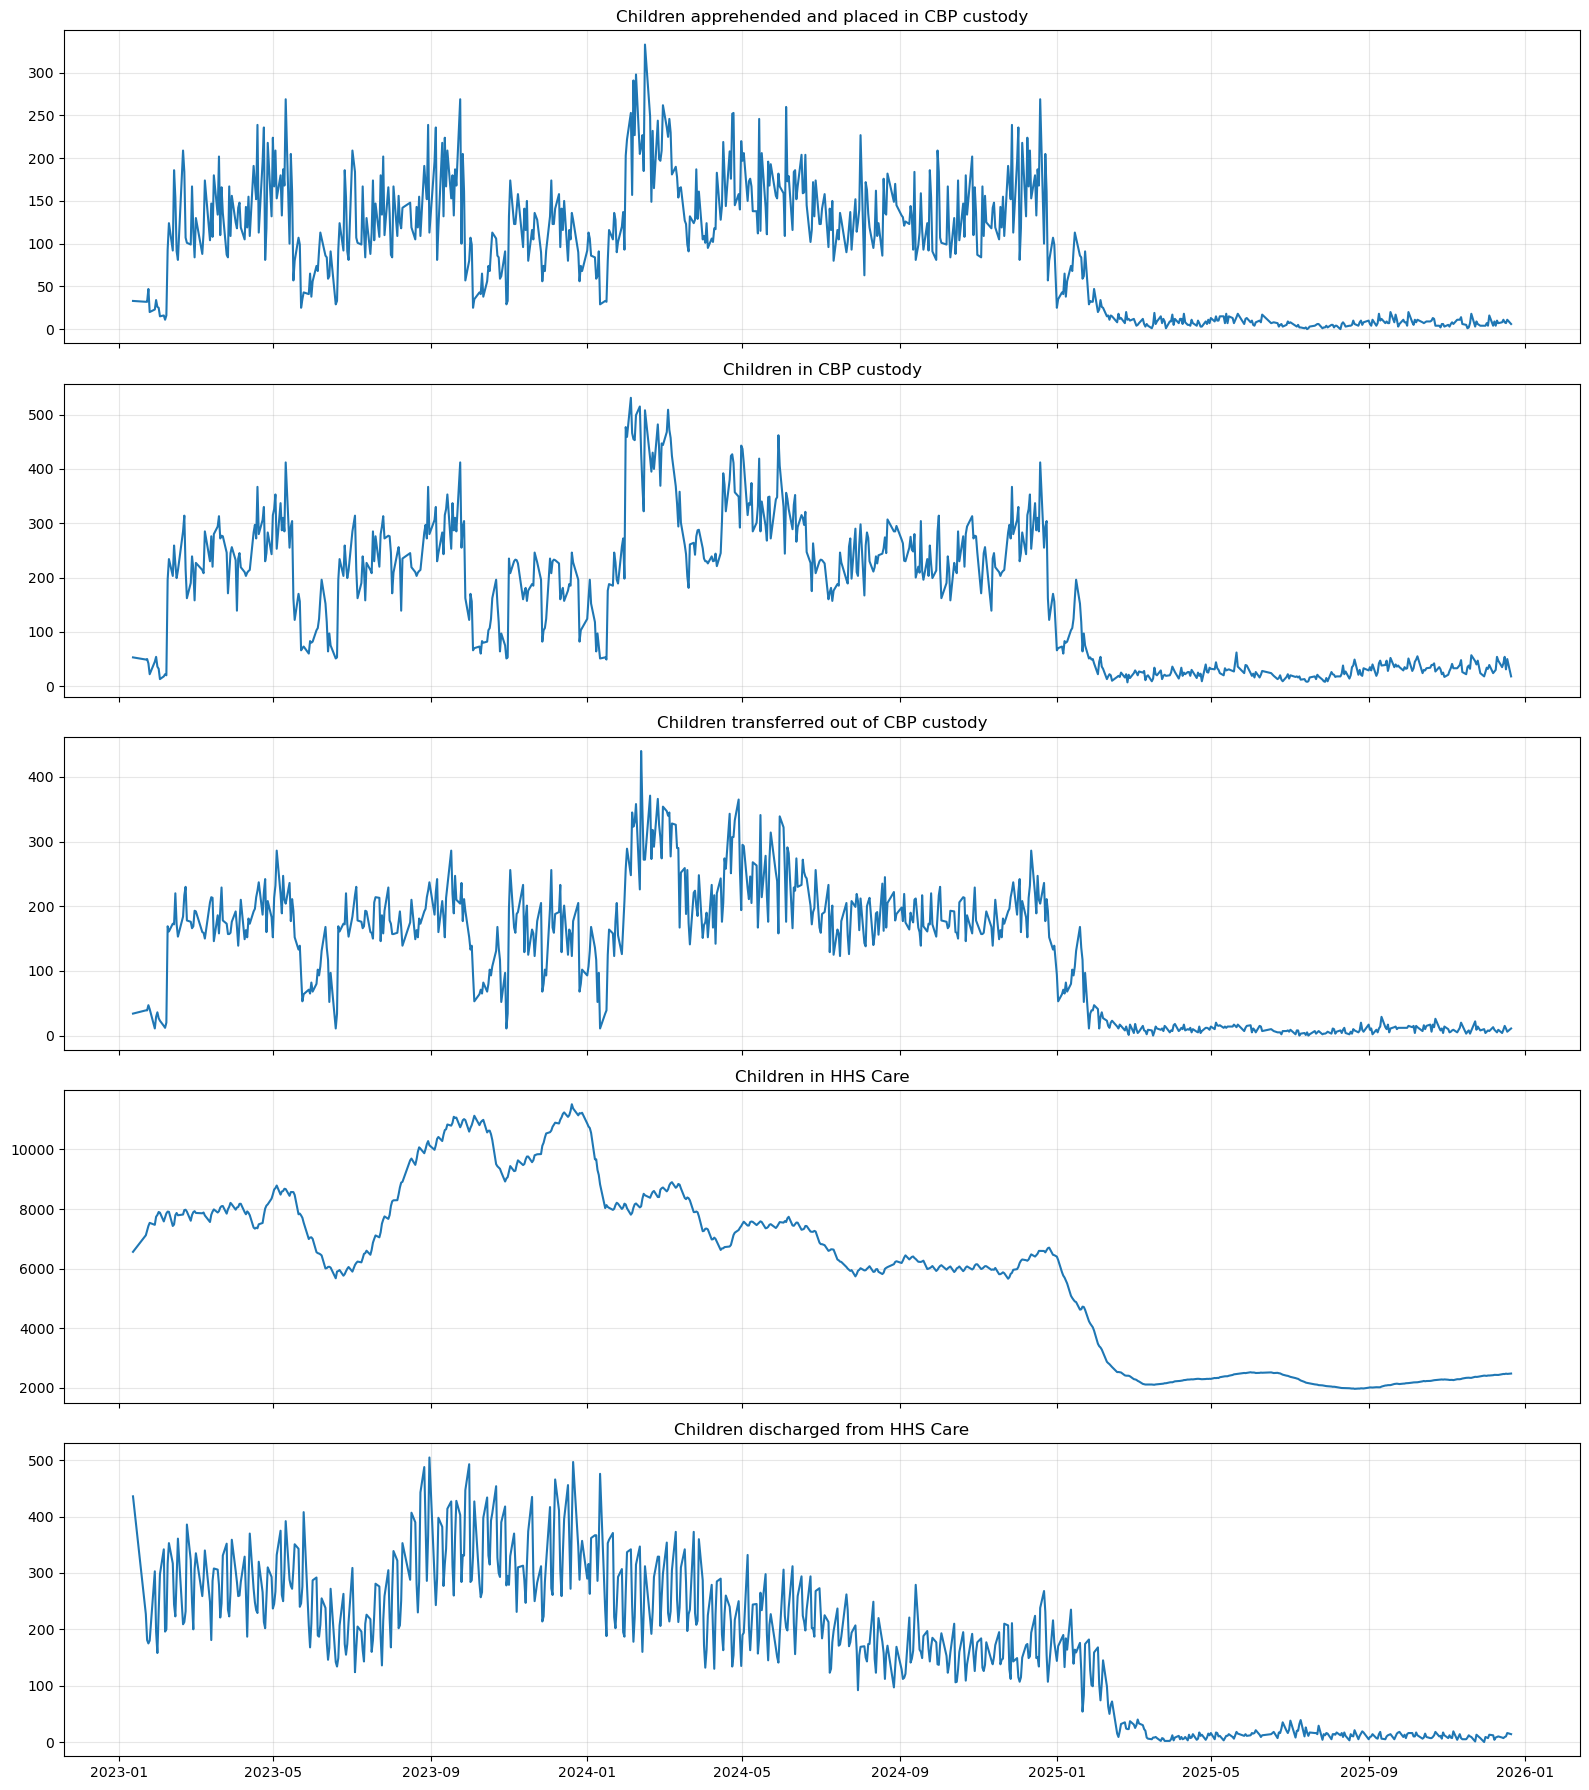

In [14]:
fig, axes = plt.subplots(5, 1, figsize=(16, 18), sharex=True)

columns = df.columns

for ax, col in zip(axes, columns):
    ax.plot(df.index, df[col], linewidth=1.5)
    ax.set_title(col)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

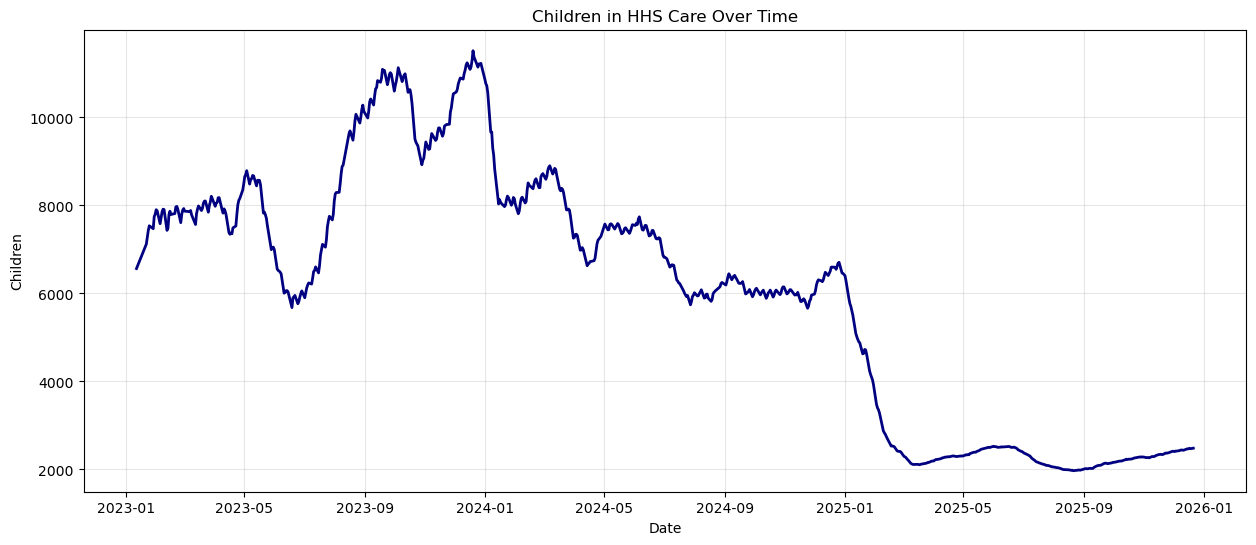

In [15]:
plt.figure(figsize=(15,6))

plt.plot(
    df.index,
    df['Children in HHS Care'],
    color='navy',
    linewidth=2
)

plt.title("Children in HHS Care Over Time")
plt.xlabel("Date")
plt.ylabel("Children")

plt.grid(alpha=0.3)

plt.show()

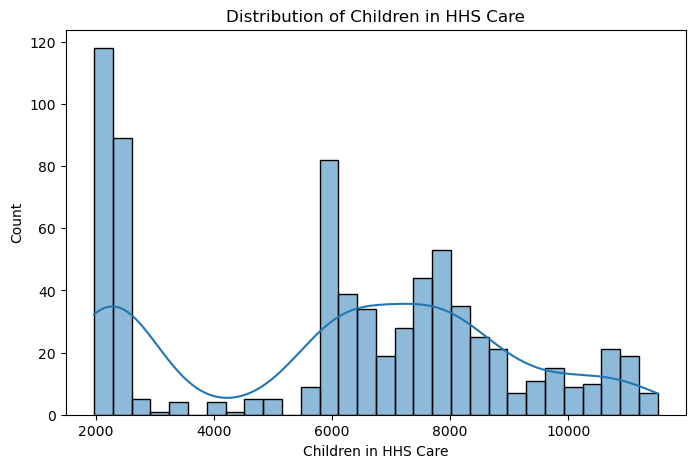

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Children in HHS Care'],
    bins=30,
    kde=True
)

plt.title("Distribution of Children in HHS Care")

plt.show()

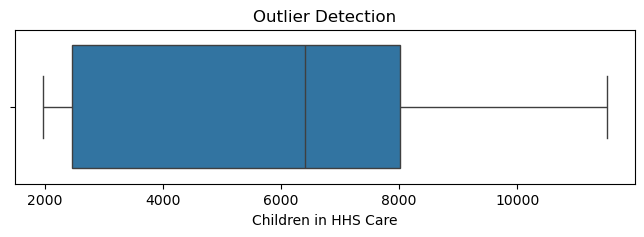

In [17]:
plt.figure(figsize=(8,2))

sns.boxplot(
    x=df['Children in HHS Care']
)

plt.title("Outlier Detection")

plt.show()

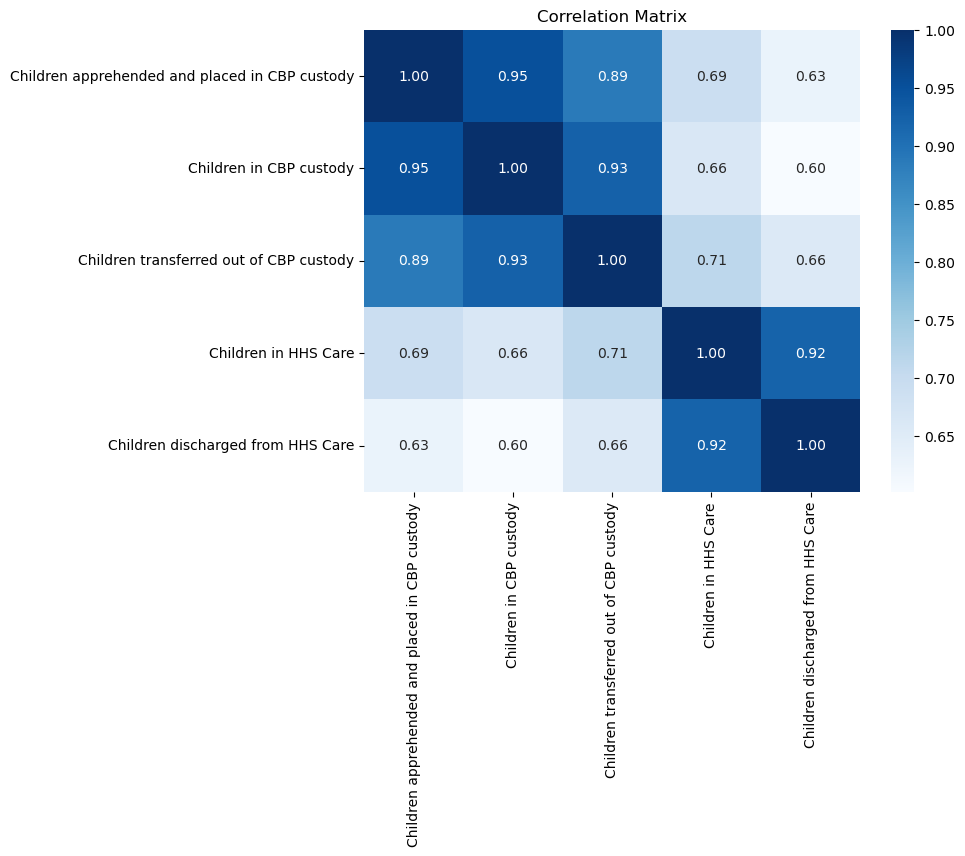

In [18]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [19]:
df['Net Pressure'] = (
    df['Children transferred out of CBP custody']
    -
    df['Children discharged from HHS Care']
)

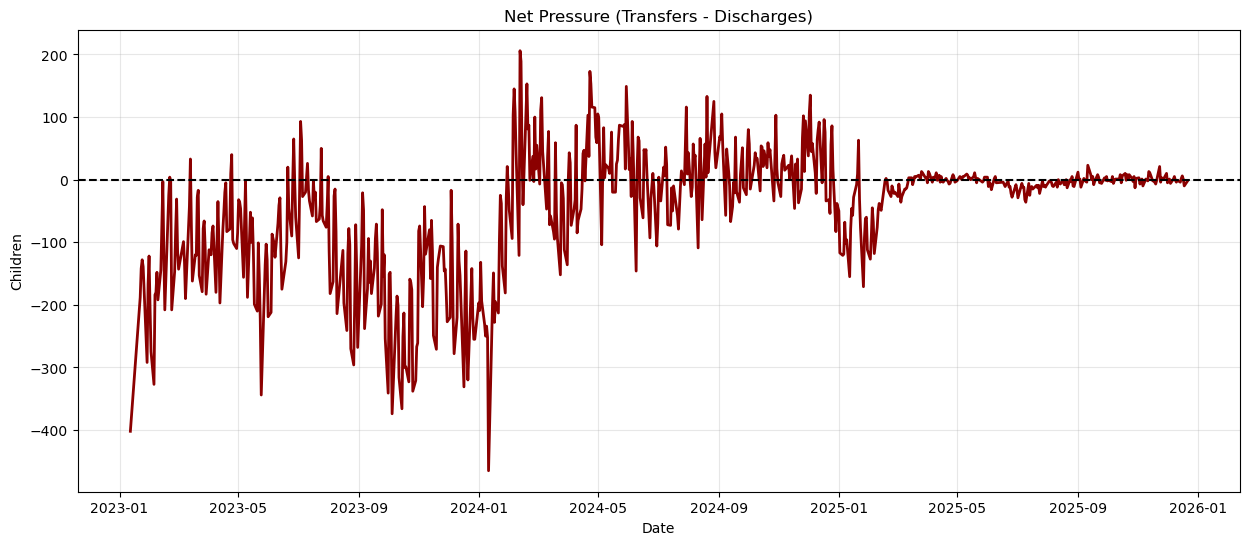

In [20]:
plt.figure(figsize=(15,6))

plt.plot(
    df.index,
    df['Net Pressure'],
    linewidth=2,
    color='darkred'
)

plt.axhline(
    y=0,
    color='black',
    linestyle='--'
)

plt.title("Net Pressure (Transfers - Discharges)")
plt.xlabel("Date")
plt.ylabel("Children")

plt.grid(alpha=0.3)

plt.show()

In [27]:
from statsmodels.tsa.seasonal import seasonal_decompose

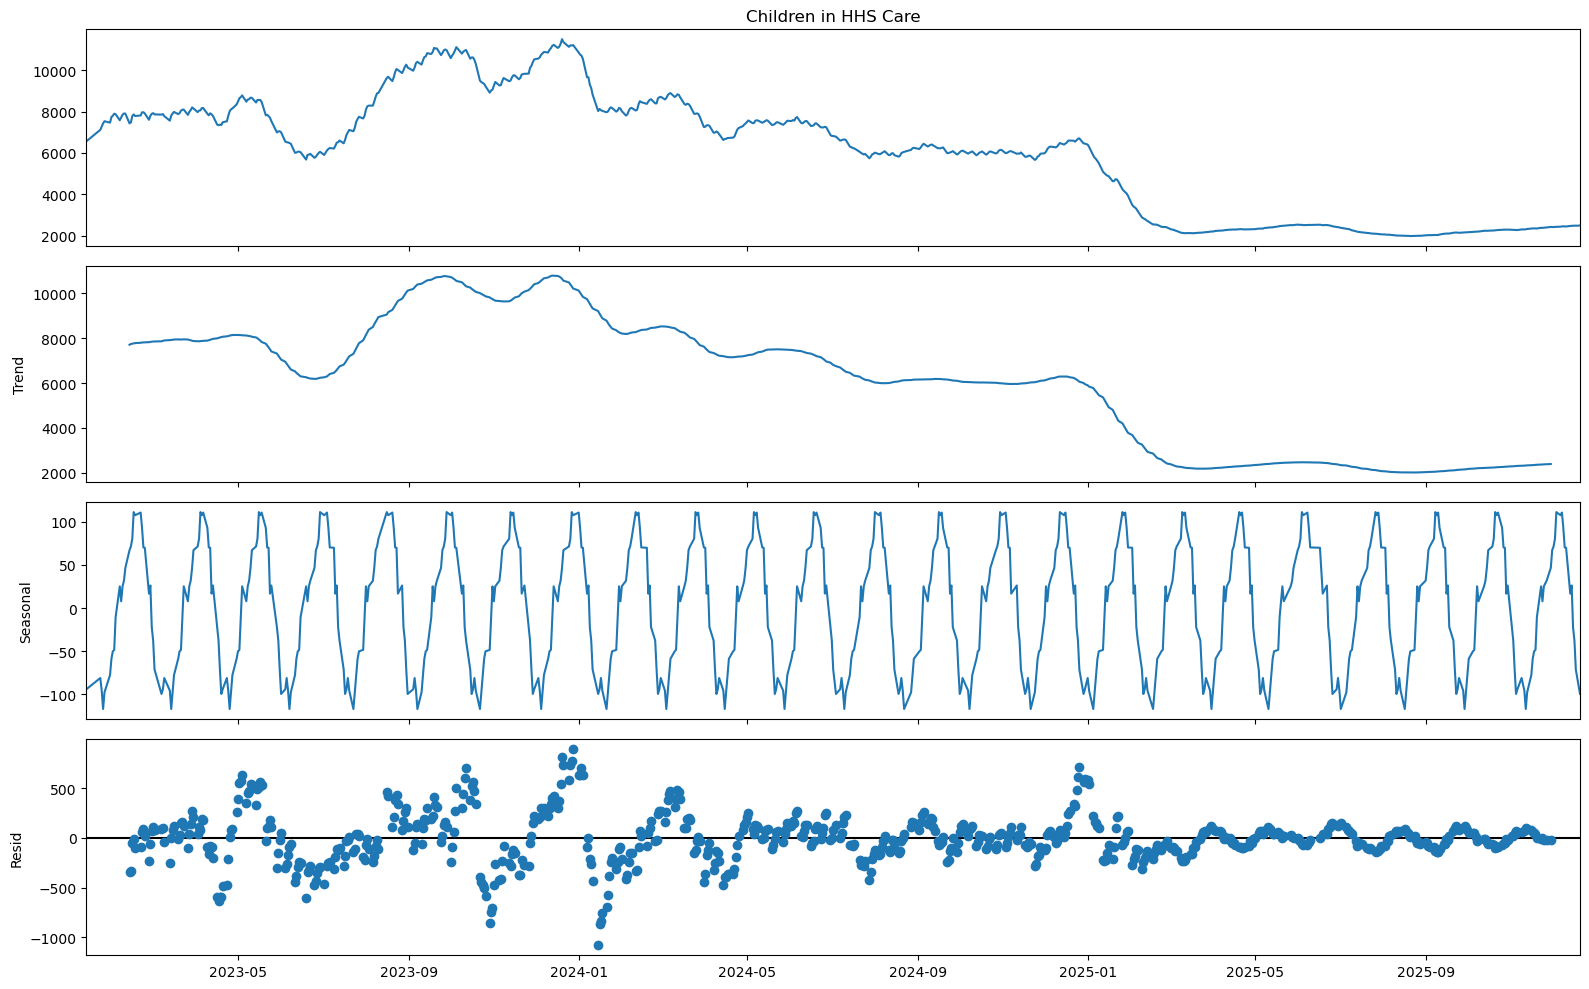

In [28]:
decomposition = seasonal_decompose(
    df['Children in HHS Care'],
    model='additive',
    period=30
)

fig = decomposition.plot()
fig.set_size_inches(16,10)

plt.tight_layout()
plt.show()

In [29]:
from statsmodels.tsa.stattools import adfuller

In [30]:
result = adfuller(df['Children in HHS Care'])

print("ADF Statistic :", result[0])
print("p-value       :", result[1])

for key, value in result[4].items():
    print(f"Critical Value ({key}) : {value}")

ADF Statistic : -1.0271046053535084
p-value       : 0.7432506157229039
Critical Value (1%) : -3.4397129207385357
Critical Value (5%) : -2.8656718422599923
Critical Value (10%) : -2.568970295481694


In [31]:
TARGET = 'Children in HHS Care'

for lag in [1, 7, 14, 30]:
    df[f'lag_{lag}'] = df[TARGET].shift(lag)

In [32]:
df[['lag_1','lag_7','lag_14','lag_30']].head(35)

,lag_1,lag_7,lag_14,lag_30
Date,,,,
2023-01-12,NaN,NaN,NaN,NaN
2023-01-22,6566.0,NaN,NaN,NaN
2023-01-23,7122.0,NaN,NaN,NaN
2023-01-24,7280.0,NaN,NaN,NaN
2023-01-25,7433.0,NaN,NaN,NaN
2023-01-29,7538.0,NaN,NaN,NaN
2023-01-30,7472.0,NaN,NaN,NaN
2023-01-31,7743.0,6566.0,NaN,NaN
2023-02-01,7803.0,7122.0,NaN,NaN


In [33]:
df['rolling_mean_7'] = (
    df[TARGET]
    .rolling(window=7)
    .mean()
)

df['rolling_mean_14'] = (
    df[TARGET]
    .rolling(window=14)
    .mean()
)

df['rolling_mean_30'] = (
    df[TARGET]
    .rolling(window=30)
    .mean()
)

In [34]:
df['rolling_std_7'] = (
    df[TARGET]
    .rolling(window=7)
    .std()
)

df['rolling_std_14'] = (
    df[TARGET]
    .rolling(window=14)
    .std()
)

df['rolling_std_30'] = (
    df[TARGET]
    .rolling(window=30)
    .std()
)

In [53]:
df['day_of_week'] = df.index.dayofweek

df['day_of_month'] = df.index.day

df['month'] = df.index.month

df['quarter'] = df.index.quarter

df['week_of_year'] = df.index.isocalendar().week.astype(int)

df['year'] = df.index.year

In [54]:
import numpy as np

# Weekly cycle
df['dayofweek_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dayofweek_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

# Monthly cycle
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

In [55]:
df['Net_Pressure'] = (
    df['Children transferred out of CBP custody']
    -
    df['Children discharged from HHS Care']
)

In [56]:
df['Transfer_Discharge_Ratio'] = (
    df['Children transferred out of CBP custody']
    /
    (df['Children discharged from HHS Care'] + 1)
)

In [57]:
df['HHS_Daily_Change'] = df[TARGET].diff()

In [58]:
df['HHS_Growth_Rate'] = df[TARGET].pct_change()

In [59]:
df_model = df.dropna().copy()

In [60]:
TARGET = 'Children in HHS Care'

In [63]:
FEATURES = [
    'Children apprehended and placed in CBP custody',
    'Children in CBP custody',
    'Children transferred out of CBP custody',
    'Children discharged from HHS Care',
    'Net_Pressure',
    'Transfer_Discharge_Ratio',
    'HHS_Daily_Change',
    'HHS_Growth_Rate',
    'lag_1',
    'lag_7',
    'lag_14',
    'lag_30',
    'rolling_mean_7',
    'rolling_mean_14',
    'rolling_mean_30',
    'rolling_std_7',
    'rolling_std_14',
    'rolling_std_30',
    'day_of_week',
    'day_of_month',
    'month',
    'quarter',
    'week_of_year',
    'year',
    'dayofweek_sin',
    'dayofweek_cos',
    'month_sin',
    'month_cos',
]

In [64]:
train_size = int(len(df_model) * 0.8)

train = df_model.iloc[:train_size]

test = df_model.iloc[train_size:]

X_train = train[FEATURES]
X_test = test[FEATURES]

y_train = train[TARGET]
y_test = test[TARGET]

In [82]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

def evaluate_model(actual, predicted, model_name):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = mean_absolute_percentage_error(actual, predicted)

    accuracy = (1 - mape) * 100

    print("="*50)
    print(model_name)
    print("="*50)
    print(f"MAE      : {mae:.2f}")
    print(f"RMSE     : {rmse:.2f}")
    print(f"MAPE     : {mape:.4f}")
    print(f"Accuracy : {accuracy:.2f}%")

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "Accuracy (%)": accuracy
    }

In [83]:
results = []

In [84]:
naive_forecast = y_test.shift(1)

naive_forecast.iloc[0] = y_train.iloc[-1]

In [85]:
result = evaluate_model(
    y_test,
    naive_forecast,
    "Naive Forecast"
)

results.append(result)

Naive Forecast
MAE      : 10.27
RMSE     : 14.09
MAPE     : 0.0046
Accuracy : 99.54%


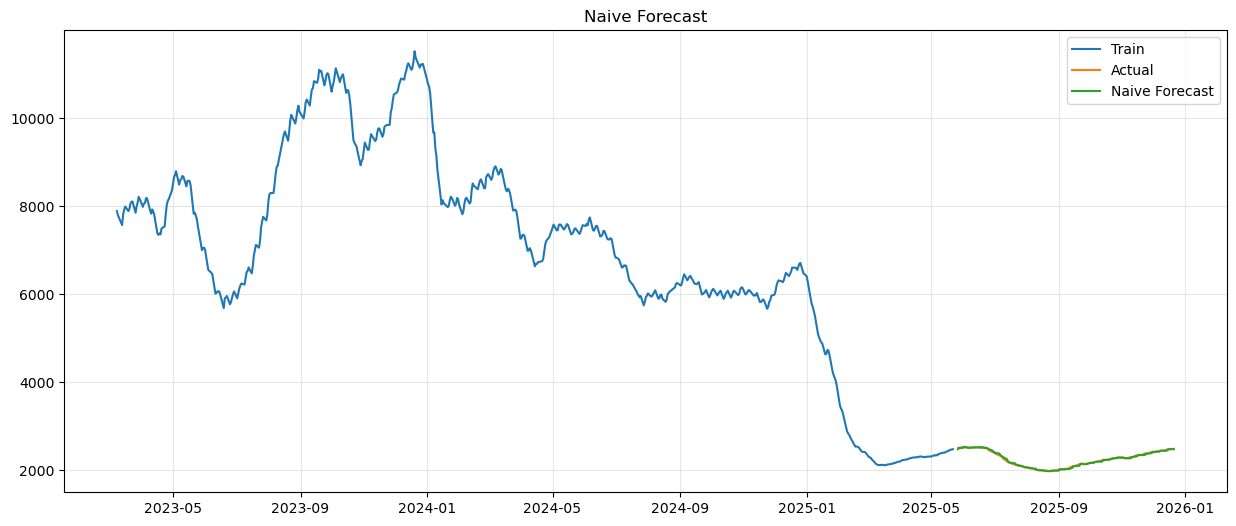

In [86]:
plt.figure(figsize=(15,6))

plt.plot(
    y_train.index,
    y_train,
    label="Train"
)

plt.plot(
    y_test.index,
    y_test,
    label="Actual"
)

plt.plot(
    y_test.index,
    naive_forecast,
    label="Naive Forecast"
)

plt.title("Naive Forecast")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [87]:
window = 7

history = list(y_train)

moving_predictions = []

for actual in y_test:

    prediction = np.mean(history[-window:])

    moving_predictions.append(prediction)

    history.append(actual)

In [88]:
moving_predictions = pd.Series(
    moving_predictions,
    index=y_test.index
)

In [89]:
result = evaluate_model(
    y_test,
    moving_predictions,
    "Moving Average"
)

results.append(result)

Moving Average
MAE      : 32.56
RMSE     : 40.14
MAPE     : 0.0146
Accuracy : 98.54%


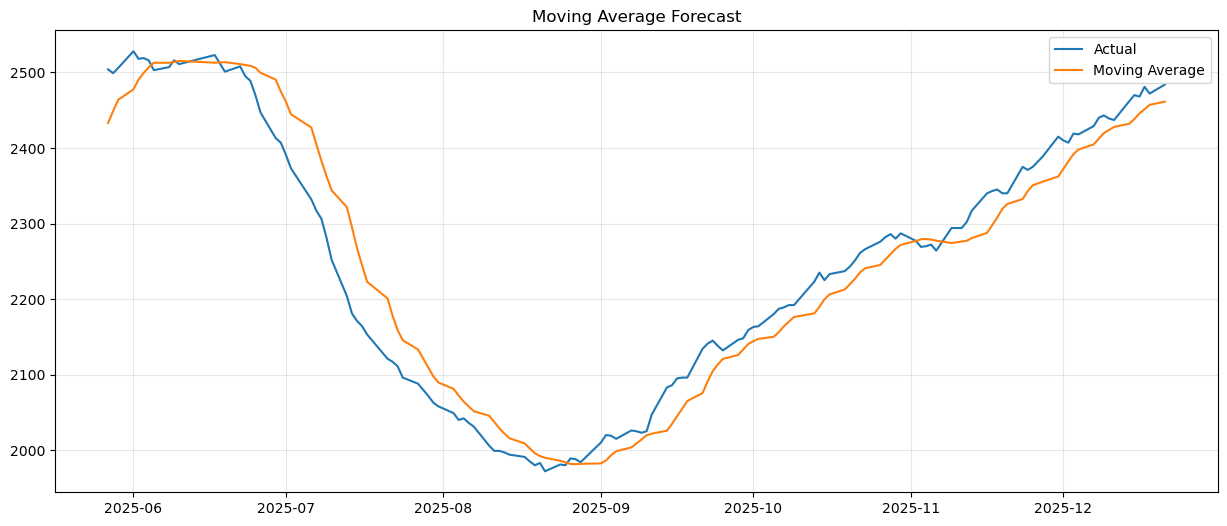

In [90]:
plt.figure(figsize=(15,6))

plt.plot(
    y_test.index,
    y_test,
    label="Actual"
)

plt.plot(
    y_test.index,
    moving_predictions,
    label="Moving Average"
)

plt.title("Moving Average Forecast")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [91]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [92]:
exp_model = ExponentialSmoothing(
    y_train,
    trend='add',
    seasonal=None
)

exp_fit = exp_model.fit()

c:\Users\mohit\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [93]:
exp_predictions = pd.Series(
    exp_predictions.values,
    index=y_test.index
)

In [94]:
result = evaluate_model(
    y_test,
    exp_predictions,
    "Exponential Smoothing"
)

results.append(result)

Exponential Smoothing
MAE      : 974.75
RMSE     : 1072.02
MAPE     : 0.4420
Accuracy : 55.80%


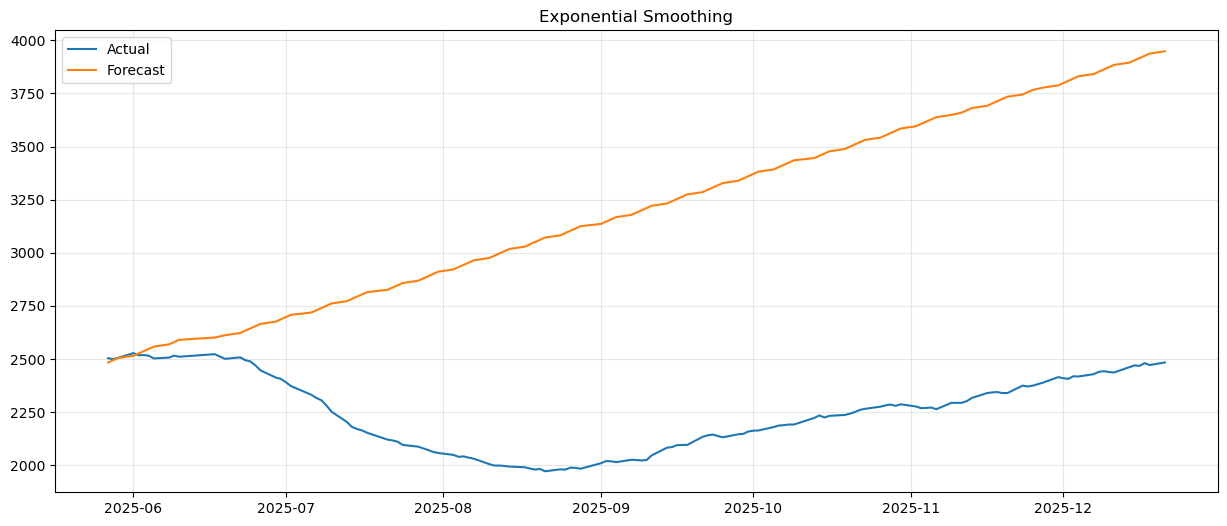

In [95]:
plt.figure(figsize=(15,6))

plt.plot(
    y_test.index,
    y_test,
    label="Actual"
)

plt.plot(
    y_test.index,
    exp_predictions,
    label="Forecast"
)

plt.title("Exponential Smoothing")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [81]:
pd.DataFrame(results)

,Model,MAE,RMSE,MAPE
0,Naive Forecast,10.268116,14.090546,0.004555
1,Moving Average,32.563147,40.139464,0.014569
2,Exponential Smoothing,974.746092,1072.015086,0.441975


In [96]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

In [97]:
result = adfuller(df['Children in HHS Care'])

<Figure size 1200x500 with 0 Axes>

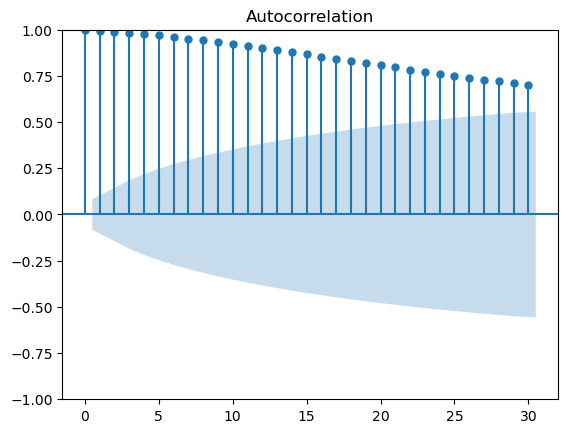

In [98]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(12,5))
plot_acf(y_train, lags=30)
plt.show()

<Figure size 1200x500 with 0 Axes>

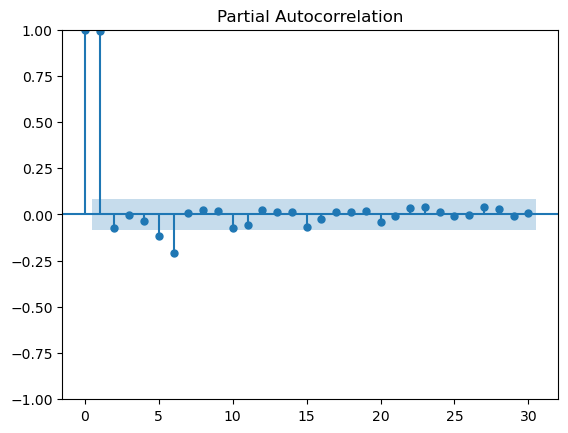

In [99]:
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(12,5))
plot_pacf(y_train, lags=30, method='ywm')
plt.show()

In [100]:
from statsmodels.tsa.arima.model import ARIMA

orders = [
    (1,1,0),
    (0,1,1),
    (1,1,1),
    (2,1,1),
    (1,1,2),
    (2,1,2)
]

aic_results = []

for order in orders:

    model = ARIMA(y_train, order=order)

    fit = model.fit()

    aic_results.append({
        "Order": order,
        "AIC": fit.aic,
        "BIC": fit.bic
    })

pd.DataFrame(aic_results).sort_values("AIC")

c:\Users\mohit\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\mohit\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\mohit\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\mohit\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(d

,Order,AIC,BIC
5,"(2, 1, 2)",7011.008264,7032.566938
4,"(1, 1, 2)",7029.160473,7046.407412
3,"(2, 1, 1)",7041.402406,7058.649345
0,"(1, 1, 0)",7053.358518,7061.981988
1,"(0, 1, 1)",7053.537076,7062.160545
2,"(1, 1, 1)",7055.276693,7068.211897


In [101]:
best_model = ARIMA(
    y_train,
    order=(2,1,2)
)

best_fit = best_model.fit()

c:\Users\mohit\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\mohit\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\mohit\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [102]:
print(best_fit.summary())

                                SARIMAX Results                                 
Dep. Variable:     Children in HHS Care   No. Observations:                  552
Model:                   ARIMA(2, 1, 2)   Log Likelihood               -3500.504
Date:                  Sat, 27 Jun 2026   AIC                           7011.008
Time:                          19:47:31   BIC                           7032.567
Sample:                               0   HQIC                          7019.432
                                  - 552                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1114      0.071      1.563      0.118      -0.028       0.251
ar.L2          0.7537      0.052     14.494      0.000       0.652       0.856
ma.L1          0.1041      0.072    

In [103]:
arima_forecast = best_fit.forecast(
    steps=len(y_test)
)

arima_forecast = pd.Series(
    arima_forecast.values,
    index=y_test.index
)

c:\Users\mohit\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [104]:
result = evaluate_model(
    y_test,
    arima_forecast,
    "ARIMA (2,1,2)"
)

results.append(result)

ARIMA (2,1,2)
MAE      : 310.91
RMSE     : 359.70
MAPE     : 0.1458
Accuracy : 85.42%


In [105]:
forecast_object = best_fit.get_forecast(
    steps=len(y_test)
)

confidence_interval = forecast_object.conf_int()

confidence_interval.index = y_test.index

c:\Users\mohit\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


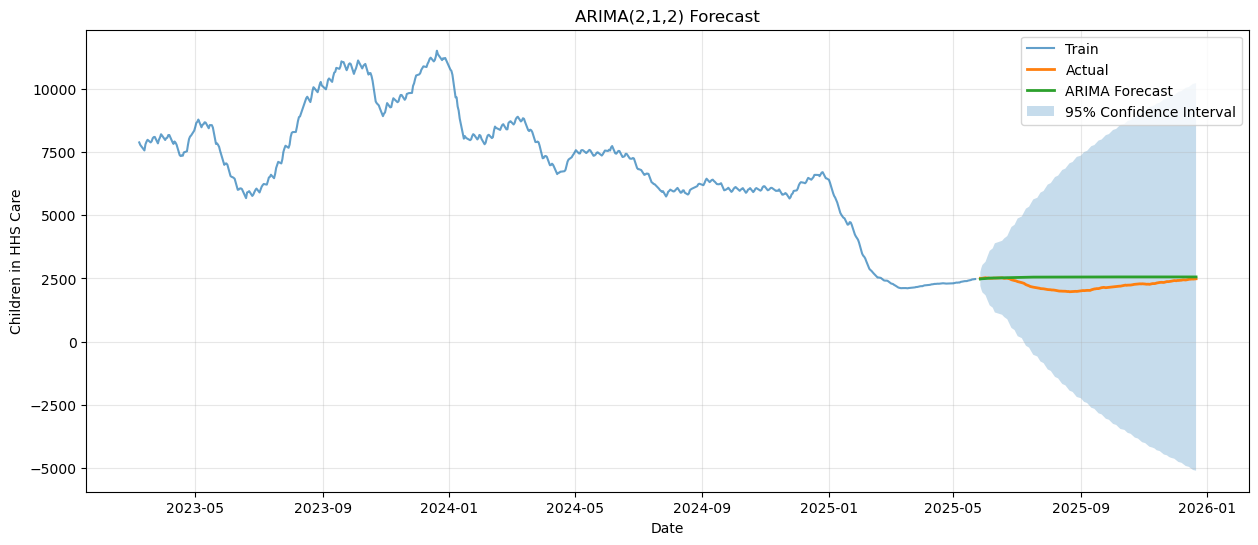

In [109]:
plt.figure(figsize=(15,6))

plt.plot(
    y_train.index,
    y_train,
    label='Train',
    alpha=0.7
)

plt.plot(
    y_test.index,
    y_test,
    label='Actual',
    linewidth=2
)

plt.plot(
    y_test.index,
    arima_forecast,
    label='ARIMA Forecast',
    linewidth=2
)

plt.fill_between(
    y_test.index,
    confidence_interval.iloc[:,0],
    confidence_interval.iloc[:,1],
    alpha=0.25,
    label='95% Confidence Interval'
)

plt.title("ARIMA(2,1,2) Forecast")
plt.xlabel("Date")
plt.ylabel("Children in HHS Care")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [107]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="RMSE"
)

results_df

,Model,MAE,RMSE,MAPE,Accuracy (%)
0,Naive Forecast,10.268116,14.090546,0.004555,99.544531
1,Moving Average,32.563147,40.139464,0.014569,98.543117
3,"ARIMA (2,1,2)",310.905126,359.701923,0.145839,85.416139
2,Exponential Smoothing,974.746092,1072.015086,0.441975,55.802502


In [112]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings

warnings.filterwarnings("ignore")

In [113]:
sarima_orders = [
    ((1,1,1), (1,1,1,7)),
    ((2,1,2), (1,1,1,7)),
    ((2,1,1), (1,1,1,7)),
    ((1,1,2), (1,1,1,7)),
    ((2,1,2), (0,1,1,7)),
    ((2,1,2), (1,1,0,7))
]

In [114]:
sarima_results = []

for order, seasonal_order in sarima_orders:

    try:

        model = SARIMAX(
            y_train,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fit = model.fit(disp=False)

        sarima_results.append({
            "Order": order,
            "Seasonal": seasonal_order,
            "AIC": fit.aic,
            "BIC": fit.bic
        })

    except Exception as e:
        print(f"Failed: {order} {seasonal_order}")

In [115]:
sarima_df = (
    pd.DataFrame(sarima_results)
      .sort_values("AIC")
      .reset_index(drop=True)
)

sarima_df

,Order,Seasonal,AIC,BIC
0,"(2, 1, 2)","(1, 1, 1, 7)",6787.845535,6817.808306
1,"(1, 1, 2)","(1, 1, 1, 7)",6793.335343,6819.017719
2,"(2, 1, 2)","(0, 1, 1, 7)",6802.752217,6828.434592
3,"(2, 1, 1)","(1, 1, 1, 7)",6814.533495,6840.227095
4,"(1, 1, 1)","(1, 1, 1, 7)",6822.395617,6843.806951
5,"(2, 1, 2)","(1, 1, 0, 7)",6930.303100,6955.996701


In [116]:
best_sarima = SARIMAX(
    y_train,
    order=(2,1,2),
    seasonal_order=(1,1,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = best_sarima.fit(disp=False)

In [117]:
print(sarima_fit.summary())

                                      SARIMAX Results                                      
Dep. Variable:                Children in HHS Care   No. Observations:                  552
Model:             SARIMAX(2, 1, 2)x(1, 1, [1], 7)   Log Likelihood               -3386.923
Date:                             Sat, 27 Jun 2026   AIC                           6787.846
Time:                                     19:57:59   BIC                           6817.808
Sample:                                          0   HQIC                          6799.570
                                             - 552                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4572      0.019     24.085      0.000       0.420       0.494
ar.L2         -0.9445      

In [118]:
sarima_forecast = sarima_fit.forecast(
    steps=len(y_test)
)

sarima_forecast = pd.Series(
    sarima_forecast.values,
    index=y_test.index
)

In [119]:
result = evaluate_model(
    y_test,
    sarima_forecast,
    "SARIMA (2,1,2)(1,1,1,7)"
)

results.append(result)

SARIMA (2,1,2)(1,1,1,7)
MAE      : 463.07
RMSE     : 644.97
MAPE     : 0.2003
Accuracy : 79.97%


In [120]:
forecast = sarima_fit.get_forecast(
    steps=len(y_test)
)

confidence_interval = forecast.conf_int()

confidence_interval.index = y_test.index

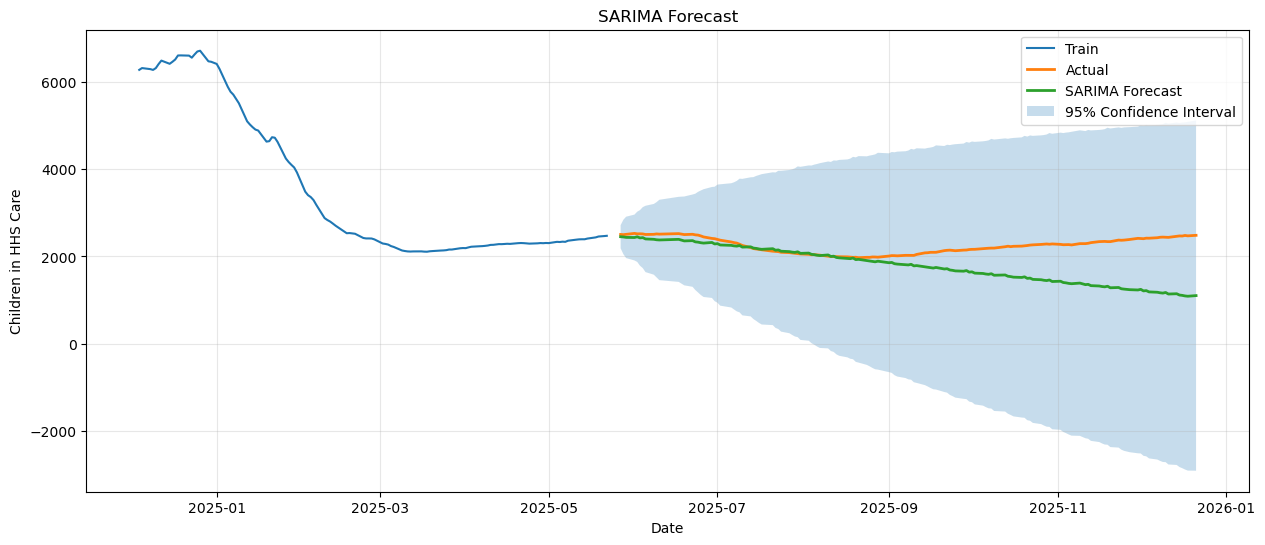

In [121]:
plt.figure(figsize=(15,6))

plt.plot(
    y_train.iloc[-120:].index,
    y_train.iloc[-120:],
    label='Train'
)

plt.plot(
    y_test.index,
    y_test,
    linewidth=2,
    label='Actual'
)

plt.plot(
    y_test.index,
    sarima_forecast,
    linewidth=2,
    label='SARIMA Forecast'
)

plt.fill_between(
    y_test.index,
    confidence_interval.iloc[:,0],
    confidence_interval.iloc[:,1],
    alpha=0.25,
    label='95% Confidence Interval'
)

plt.title("SARIMA Forecast")

plt.xlabel("Date")

plt.ylabel("Children in HHS Care")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [122]:
results_df = (
    pd.DataFrame(results)
      .sort_values("RMSE")
      .reset_index(drop=True)
)

results_df

,Model,MAE,RMSE,MAPE,Accuracy (%)
0,Naive Forecast,10.268116,14.090546,0.004555,99.544531
1,Moving Average,32.563147,40.139464,0.014569,98.543117
2,"ARIMA (2,1,2)",310.905126,359.701923,0.145839,85.416139
3,"SARIMA (2,1,2)(1,1,1,7)",463.065066,644.971537,0.200319,79.968061
4,Exponential Smoothing,974.746092,1072.015086,0.441975,55.802502


In [123]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

In [124]:
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

In [125]:
param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [5, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [126]:
rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    cv=5,
    random_state=42,
    n_jobs=-1
)

In [127]:
rf_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [5, 10, 15, 20, None],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='neg_root_mean_squared_error')

In [128]:
print("Best Parameters:")
print(rf_search.best_params_)

Best Parameters:
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}


In [129]:
best_rf = rf_search.best_estimator_

In [130]:
rf_predictions = best_rf.predict(X_test)

rf_predictions = pd.Series(
    rf_predictions,
    index=y_test.index
)

In [131]:
result = evaluate_model(
    y_test,
    rf_predictions,
    "Random Forest"
)

results.append(result)

Random Forest
MAE      : 200.17
RMSE     : 220.89
MAPE     : 0.0927
Accuracy : 90.73%


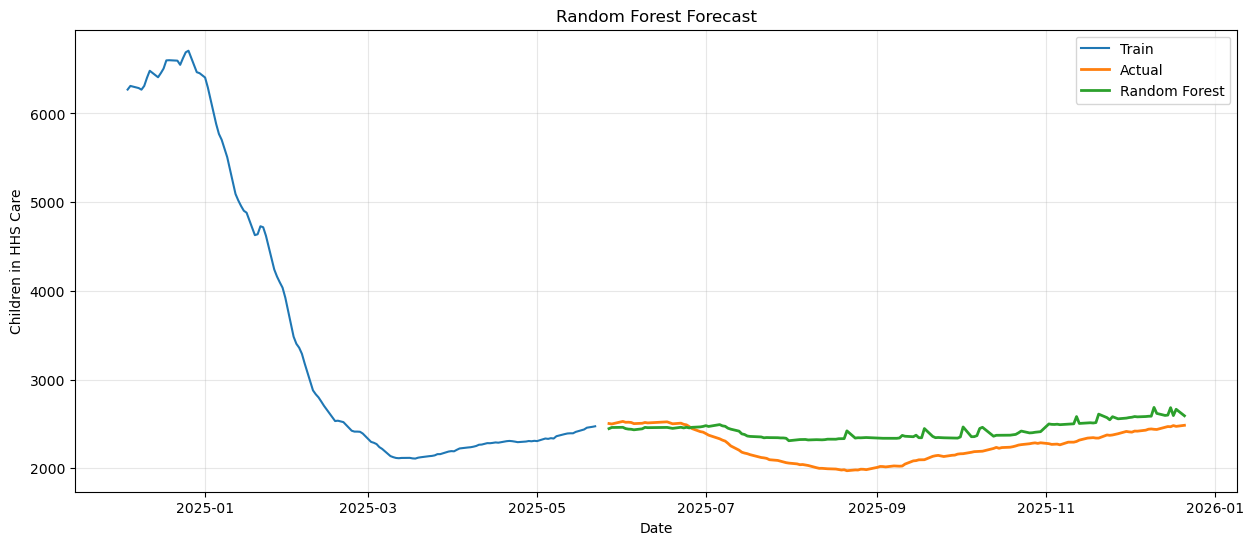

In [132]:
plt.figure(figsize=(15,6))

plt.plot(
    y_train.iloc[-120:].index,
    y_train.iloc[-120:],
    label="Train"
)

plt.plot(
    y_test.index,
    y_test,
    linewidth=2,
    label="Actual"
)

plt.plot(
    y_test.index,
    rf_predictions,
    linewidth=2,
    label="Random Forest"
)

plt.title("Random Forest Forecast")

plt.xlabel("Date")
plt.ylabel("Children in HHS Care")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [133]:
importance = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": best_rf.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance

,Feature,Importance
12,rolling_mean_7,0.208527
8,lag_1,0.173731
13,rolling_mean_14,0.141947
9,lag_7,0.092043
14,rolling_mean_30,0.075128
10,lag_14,0.065759
23,year,0.049431
3,Children discharged from HHS Care,0.035755
2,Children transferred out of CBP custody,0.030576
0,Children apprehended and placed in CBP custody,0.023992


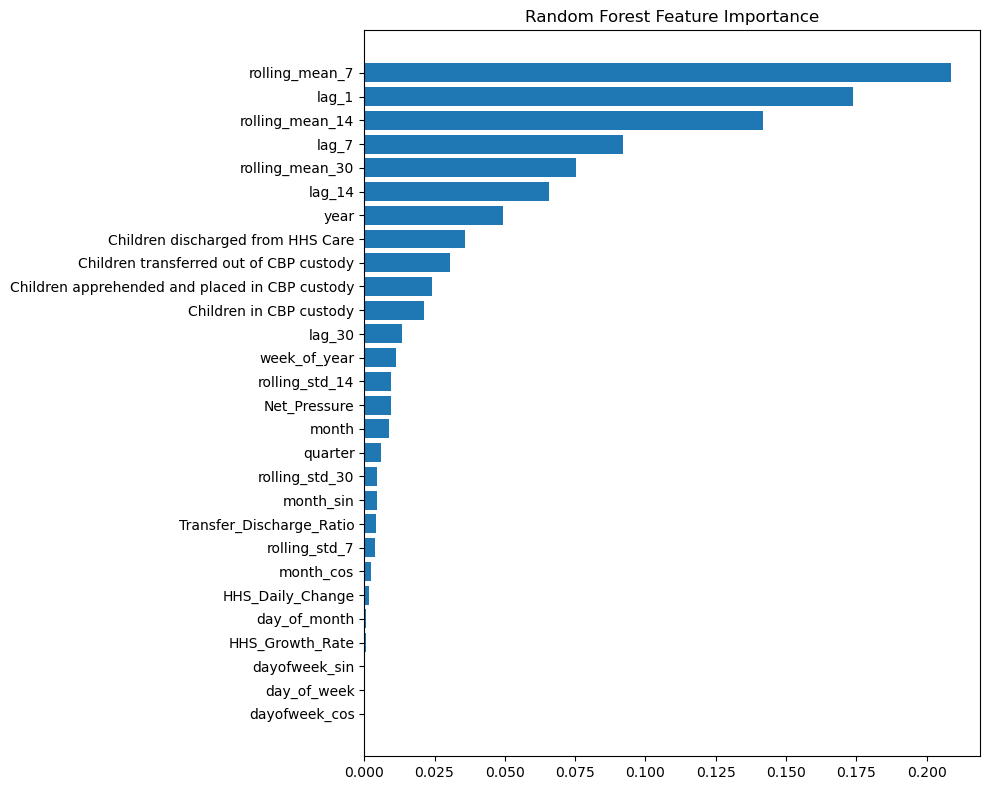

In [134]:
plt.figure(figsize=(10,8))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Random Forest Feature Importance")

plt.tight_layout()

plt.show()

In [135]:
results_df = (
    pd.DataFrame(results)
      .sort_values("RMSE")
      .reset_index(drop=True)
)

results_df

,Model,MAE,RMSE,MAPE,Accuracy (%)
0,Naive Forecast,10.268116,14.090546,0.004555,99.544531
1,Moving Average,32.563147,40.139464,0.014569,98.543117
2,Random Forest,200.165430,220.890618,0.092720,90.728005
3,"ARIMA (2,1,2)",310.905126,359.701923,0.145839,85.416139
4,"SARIMA (2,1,2)(1,1,1,7)",463.065066,644.971537,0.200319,79.968061
5,Exponential Smoothing,974.746092,1072.015086,0.441975,55.802502


In [136]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV

In [137]:
gbr = GradientBoostingRegressor(
    random_state=42
)

In [138]:
param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4, 5],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "subsample": [0.7, 0.8, 0.9, 1.0]
}

In [139]:
gbr_search = RandomizedSearchCV(
    estimator=gbr,
    param_distributions=param_grid,
    n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=5,
    random_state=42,
    n_jobs=-1
)

In [140]:
gbr_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=GradientBoostingRegressor(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [2, 3, 4, 5],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='neg_root_mean_squared_error')

In [141]:
print("Best Parameters:")
print(gbr_search.best_params_)

Best Parameters:
{'subsample': 1.0, 'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 2, 'learning_rate': 0.1}


In [142]:
best_gbr = gbr_search.best_estimator_

In [143]:
gbr_predictions = best_gbr.predict(X_test)

gbr_predictions = pd.Series(
    gbr_predictions,
    index=y_test.index
)

In [144]:
result = evaluate_model(
    y_test,
    gbr_predictions,
    "Gradient Boosting"
)

results.append(result)

Gradient Boosting
MAE      : 49.36
RMSE     : 71.93
MAPE     : 0.0235
Accuracy : 97.65%


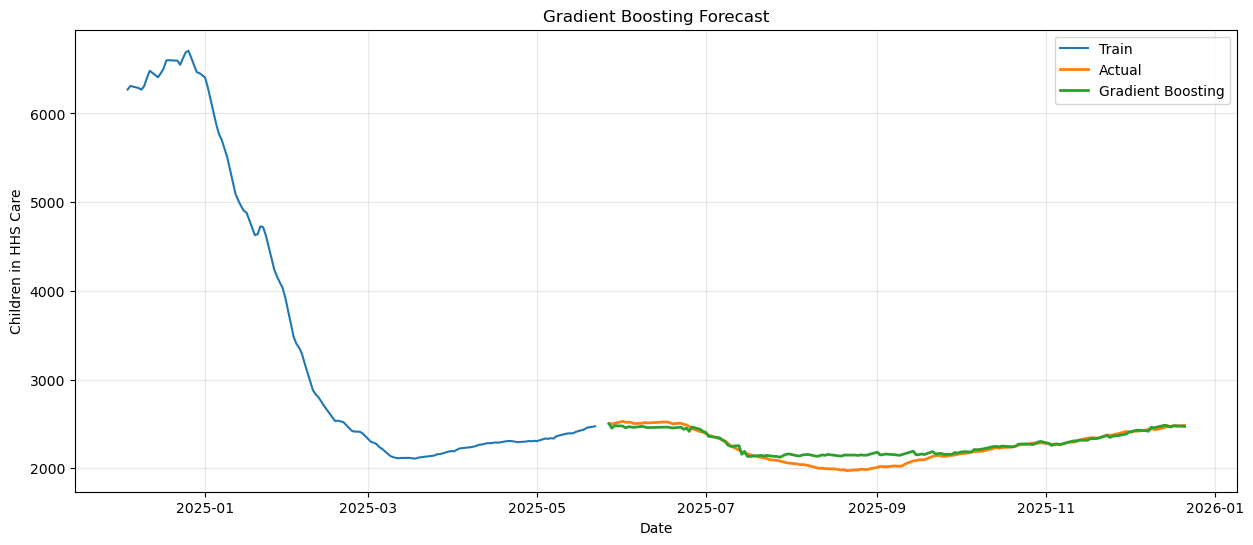

In [145]:
plt.figure(figsize=(15,6))

plt.plot(
    y_train.iloc[-120:].index,
    y_train.iloc[-120:],
    label="Train"
)

plt.plot(
    y_test.index,
    y_test,
    linewidth=2,
    label="Actual"
)

plt.plot(
    y_test.index,
    gbr_predictions,
    linewidth=2,
    label="Gradient Boosting"
)

plt.title("Gradient Boosting Forecast")

plt.xlabel("Date")
plt.ylabel("Children in HHS Care")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [146]:
gbr_importance = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": best_gbr.feature_importances_
})

gbr_importance = gbr_importance.sort_values(
    by="Importance",
    ascending=False
)

gbr_importance

,Feature,Importance
8,lag_1,0.725401
12,rolling_mean_7,0.145662
13,rolling_mean_14,0.101593
10,lag_14,0.012353
0,Children apprehended and placed in CBP custody,0.005525
22,week_of_year,0.004025
6,HHS_Daily_Change,0.001230
7,HHS_Growth_Rate,0.001204
9,lag_7,0.000876
23,year,0.000808


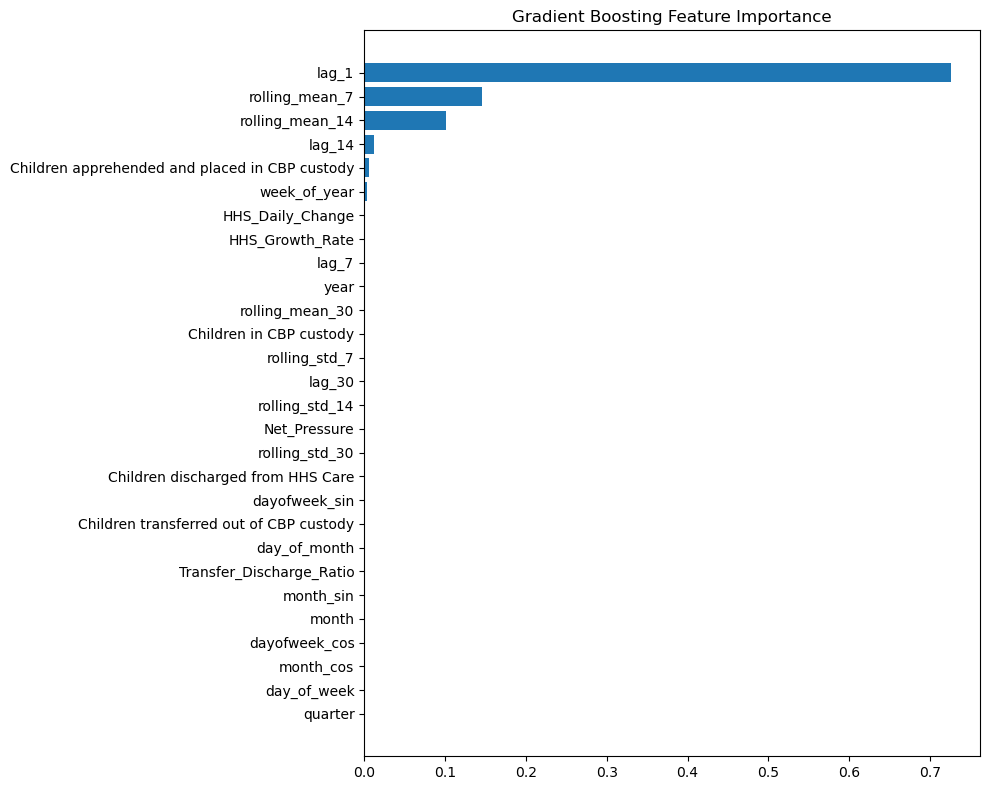

In [147]:
plt.figure(figsize=(10,8))

plt.barh(
    gbr_importance["Feature"],
    gbr_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Gradient Boosting Feature Importance")

plt.tight_layout()

plt.show()

In [148]:
results_df = (
    pd.DataFrame(results)
      .sort_values("RMSE")
      .reset_index(drop=True)
)

results_df

,Model,MAE,RMSE,MAPE,Accuracy (%)
0,Naive Forecast,10.268116,14.090546,0.004555,99.544531
1,Moving Average,32.563147,40.139464,0.014569,98.543117
2,Gradient Boosting,49.364938,71.934127,0.023482,97.651758
3,Random Forest,200.165430,220.890618,0.092720,90.728005
4,"ARIMA (2,1,2)",310.905126,359.701923,0.145839,85.416139
5,"SARIMA (2,1,2)(1,1,1,7)",463.065066,644.971537,0.200319,79.968061
6,Exponential Smoothing,974.746092,1072.015086,0.441975,55.802502


In [151]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

In [152]:
xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

In [153]:
param_grid = {

    "n_estimators": [100, 200, 300, 500],

    "max_depth": [2,3,4,5,6],

    "learning_rate": [0.01,0.05,0.1,0.2],

    "subsample": [0.7,0.8,0.9,1.0],

    "colsample_bytree": [0.7,0.8,0.9,1.0],

    "gamma": [0,0.1,0.3,0.5],

    "min_child_weight": [1,3,5]
}

In [154]:
xgb_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=5,
    random_state=42,
    n_jobs=-1
)

In [155]:
xgb_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=True,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints...
                                          n_estimators=None, n_jobs=-1,
                                          num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'gamma': [0, 0.1, 0.3, 0.5],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [2, 3, 4, 5, 6],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [100, 200, 300, 500],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='neg_root_mean_squared_error')

In [156]:
print("Best Parameters:")
print(xgb_search.best_params_)

Best Parameters:
{'subsample': 0.7, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 2, 'learning_rate': 0.2, 'gamma': 0.5, 'colsample_bytree': 0.9}


In [157]:
best_xgb = xgb_search.best_estimator_

In [158]:
xgb_predictions = best_xgb.predict(X_test)

xgb_predictions = pd.Series(
    xgb_predictions,
    index=y_test.index
)

In [159]:
result = evaluate_model(
    y_test,
    xgb_predictions,
    "XGBoost"
)

results.append(result)

XGBoost
MAE      : 66.56
RMSE     : 85.62
MAPE     : 0.0305
Accuracy : 96.95%


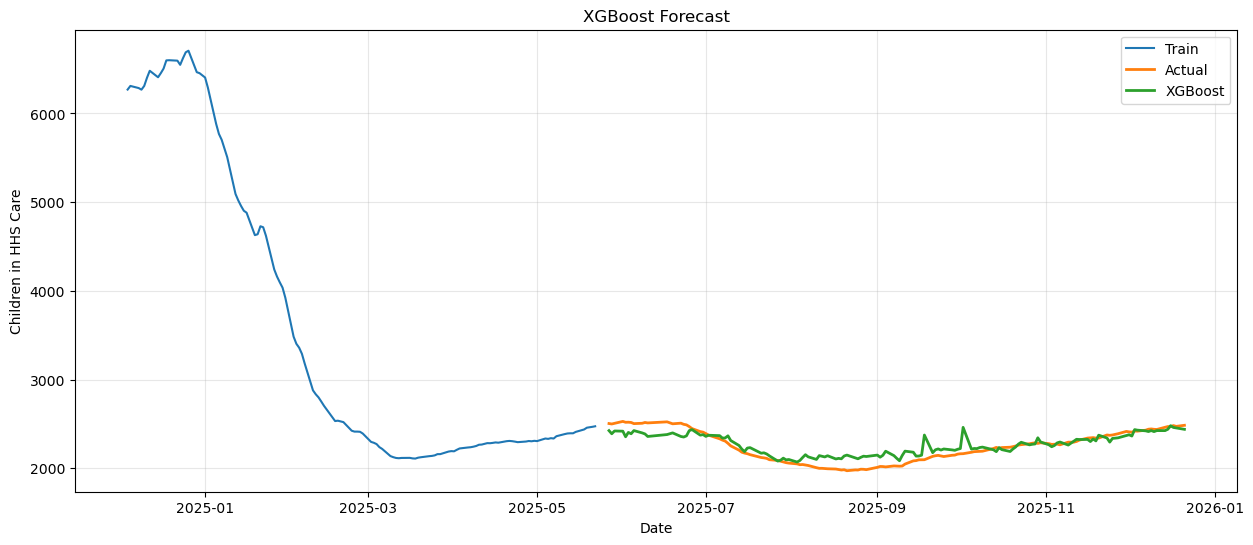

In [160]:
plt.figure(figsize=(15,6))

plt.plot(
    y_train.iloc[-120:].index,
    y_train.iloc[-120:],
    label='Train'
)

plt.plot(
    y_test.index,
    y_test,
    linewidth=2,
    label='Actual'
)

plt.plot(
    y_test.index,
    xgb_predictions,
    linewidth=2,
    label='XGBoost'
)

plt.title("XGBoost Forecast")

plt.xlabel("Date")

plt.ylabel("Children in HHS Care")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [161]:
importance = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": best_xgb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
8,lag_1,0.467665
12,rolling_mean_7,0.271470
9,lag_7,0.173056
23,year,0.035962
0,Children apprehended and placed in CBP custody,0.022416
2,Children transferred out of CBP custody,0.015493
3,Children discharged from HHS Care,0.003653
11,lag_30,0.002083
6,HHS_Daily_Change,0.001748
7,HHS_Growth_Rate,0.001459


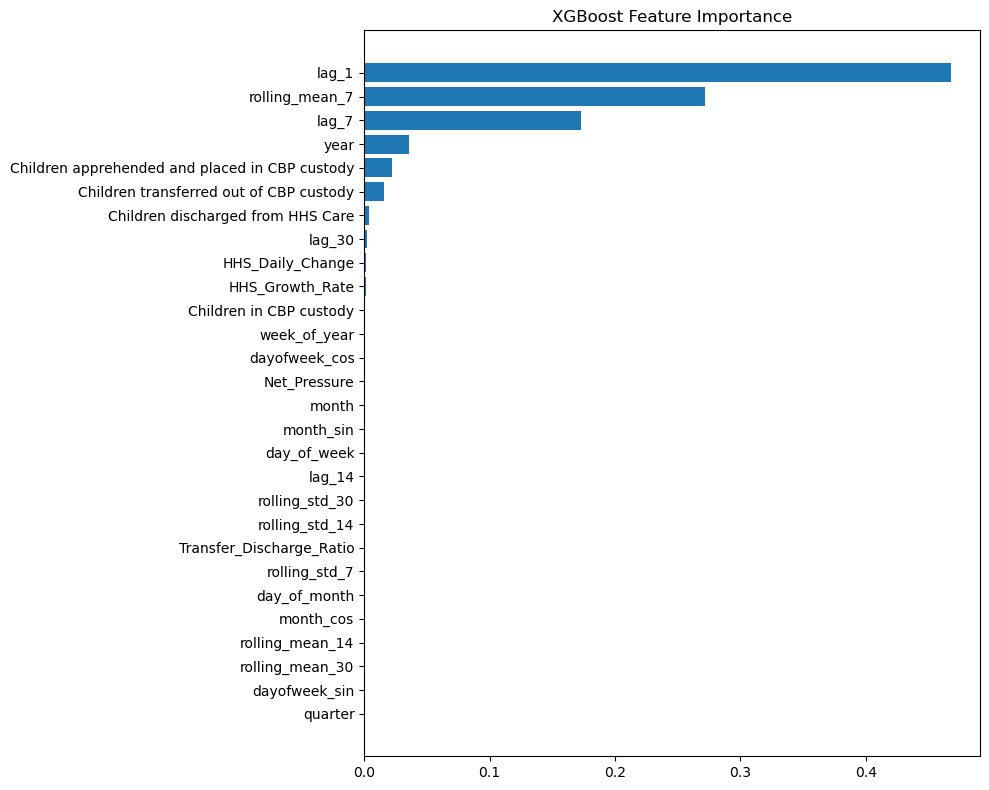

In [162]:
plt.figure(figsize=(10,8))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("XGBoost Feature Importance")

plt.tight_layout()

plt.show()

In [163]:
results_df = (
    pd.DataFrame(results)
      .sort_values("RMSE")
      .reset_index(drop=True)
)

results_df

,Model,MAE,RMSE,MAPE,Accuracy (%)
0,Naive Forecast,10.268116,14.090546,0.004555,99.544531
1,Moving Average,32.563147,40.139464,0.014569,98.543117
2,Gradient Boosting,49.364938,71.934127,0.023482,97.651758
3,XGBoost,66.562627,85.624137,0.030484,96.951637
4,Random Forest,200.165430,220.890618,0.092720,90.728005
5,"ARIMA (2,1,2)",310.905126,359.701923,0.145839,85.416139
6,"SARIMA (2,1,2)(1,1,1,7)",463.065066,644.971537,0.200319,79.968061
7,Exponential Smoothing,974.746092,1072.015086,0.441975,55.802502
